# Endo-FM on Cholec80

Frozen-backbone linear probe for phase (7-class) and tool (7-label) recognition, same methodology as `benchmark_endofm_kvasir_capsule.ipynb`. Standard 40/40 video split. CholecT45 pretraining-overlap exclusion not applied yet.

## 0. Setup

In [ ]:
import os, sys, json, glob, random, re, subprocess, getpass, zipfile
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive")
    PROJECT_ROOT = DRIVE_ROOT / "endofm-benchmark"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "einops", "timm", "gdown", "opencv-python-headless"], check=True)
else:
    DRIVE_ROOT = Path(r"E:/")
    PROJECT_ROOT = DRIVE_ROOT / "endofm-benchmark"

ENDOFM_REPO = PROJECT_ROOT / "Endo-FM"
CKPT_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results" / "cholec80"
CHOLEC80_DIR = DRIVE_ROOT / "cholec80" / "cholec80"
FRAMES_DIR = PROJECT_ROOT / "data" / "cholec80" / "extracted_frames"

for d in [CKPT_DIR, RESULTS_DIR, FRAMES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ENDOFM_REPO))

import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(0)
torch.manual_seed(0)


Mounted at /content/drive
torch: 2.11.0+cu128 | CUDA: True


## 1. Backbone

In [ ]:

if not (ENDOFM_REPO / "models" / "timesformer.py").exists():
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/med-air/Endo-FM.git", str(ENDOFM_REPO)], check=True)

CKPT_PATH = CKPT_DIR / "endo_fm.pth"
if not CKPT_PATH.exists():
    import gdown
    gdown.download(id="1H7B91Ewm4QkZRsnUk1Bn0IQch5P8C7Xl", output=str(CKPT_PATH), quiet=False)


## 2. Extract Cholec80 zip (password-prompted if needed)

In [ ]:

# extract_dir = CHOLEC80_DIR / "raw"
extract_dir = Path("/content/drive/MyDrive/endofm-benchmark/data/cholec80") if IN_COLAB else CHOLEC80_DIR / "raw"

if not extract_dir.exists() or not any(extract_dir.rglob("*")):
    zip_candidates = list(CHOLEC80_DIR.glob("*.zip"))
    if not zip_candidates:
        raise FileNotFoundError(f"No .zip found in {CHOLEC80_DIR} and no extracted data present.")
    zip_path = zip_candidates[0]
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        try:
            zf.extractall(extract_dir)
        except RuntimeError:
            pwd = getpass.getpass(f"Password for {zip_path.name}: ").encode()
            zf.extractall(extract_dir, pwd=pwd)
    print("Extracted:", extract_dir)
else:
    print("Already extracted:", extract_dir)


Already extracted: /content/drive/MyDrive/endofm-benchmark/data/cholec80


## 3. Discover videos + annotations

In [ ]:
extract_dir = Path("/content/drive/MyDrive/endofm-benchmark/data/cholec80")

In [ ]:

VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv")
all_files = list(extract_dir.rglob("*"))
print(all_files)
video_paths = [p for p in all_files if p.suffix.lower() in VIDEO_EXTS]
phase_files = [p for p in all_files if re.search(r"phase", p.name, re.IGNORECASE) and p.suffix.lower() in (".txt", ".csv")]
tool_files = [p for p in all_files if re.search(r"tool", p.name, re.IGNORECASE) and p.suffix.lower() in (".txt", ".csv")]

print(f"videos={len(video_paths)} phase_files={len(phase_files)} tool_files={len(tool_files)}")

def video_id_from_path(p):
    m = re.search(r"(\d+)", p.stem)
    return int(m.group(1)) if m else None

video_id_to_path = {video_id_from_path(p): p for p in video_paths if video_id_from_path(p) is not None}
phase_id_to_path = {video_id_from_path(p): p for p in phase_files if video_id_from_path(p) is not None}
tool_id_to_path = {video_id_from_path(p): p for p in tool_files if video_id_from_path(p) is not None}

common_ids = sorted(set(video_id_to_path) & set(phase_id_to_path) & set(tool_id_to_path))
print(f"videos with video+phase+tool: {len(common_ids)}")


KeyboardInterrupt: 

## 4. Parse labels

In [ ]:

def parse_tool_file(path):
    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
    header = lines[0].split()
    tool_names = header[1:]
    rows = []
    for line in lines[1:]:
        parts = line.split()
        if len(parts) != len(header):
            continue
        rows.append((int(parts[0]), [int(x) for x in parts[1:]]))
    return tool_names, rows

def parse_phase_file(path):
    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
    phase_by_frame = {}
    for line in lines[1:]:
        parts = line.split()
        if len(parts) != 2:
            continue
        phase_by_frame[int(parts[0])] = parts[1]
    return phase_by_frame

TOOL_NAMES = None
all_rows = []

for vid in common_ids:
    tool_names, tool_rows = parse_tool_file(tool_id_to_path[vid])
    if TOOL_NAMES is None:
        TOOL_NAMES = tool_names
    phase_by_frame = parse_phase_file(phase_id_to_path[vid])
    for frame_idx, tool_vec in tool_rows:
        phase = phase_by_frame.get(frame_idx)
        if phase is not None:
            all_rows.append((vid, frame_idx, phase, tool_vec))

all_phases = sorted({r[2] for r in all_rows})
print(f"tools={TOOL_NAMES}")
print(f"phases={all_phases}")
print(f"rows={len(all_rows)}")


NameError: name 'common_ids' is not defined

## 5. Split (videos 1-40 train, 41-80 test)

In [ ]:

TRAIN_IDS = {vid for vid in common_ids if 1 <= vid <= 40}
TEST_IDS = {vid for vid in common_ids if 41 <= vid <= 80}
train_rows = [r for r in all_rows if r[0] in TRAIN_IDS]
test_rows = [r for r in all_rows if r[0] in TEST_IDS]
print(f"train videos={len(TRAIN_IDS)} rows={len(train_rows)} | test videos={len(TEST_IDS)} rows={len(test_rows)}")


NameError: name 'common_ids' is not defined

## 6. Frame extraction

In [ ]:

import cv2
from collections import defaultdict
from tqdm import tqdm

wanted_by_video = defaultdict(set)
for vid, frame_idx, _, _ in all_rows:
    wanted_by_video[vid].add(frame_idx)

def frame_path(vid, frame_idx):
    return FRAMES_DIR / f"video{vid:02d}" / f"{frame_idx}.jpg"

def extract_frames_for_video(vid, frame_numbers):
    out_dir = FRAMES_DIR / f"video{vid:02d}"
    remaining = {fn for fn in frame_numbers if not (out_dir / f"{fn}.jpg").exists()}
    if not remaining:
        return
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_id_to_path[vid]))
    idx, target_max = 0, max(remaining)
    while idx <= target_max:
        ok, frame = cap.read()
        if not ok:
            break
        if idx in remaining:
            cv2.imwrite(str(out_dir / f"{idx}.jpg"), frame)
        idx += 1
    cap.release()

for vid, frame_numbers in tqdm(wanted_by_video.items(), desc="Extracting"):
    extract_frames_for_video(vid, frame_numbers)

def keep_available(rows):
    return [r for r in rows if frame_path(r[0], r[1]).exists()]

train_rows = keep_available(train_rows)
test_rows = keep_available(test_rows)
print(f"usable -- train={len(train_rows)} test={len(test_rows)}")


Extracting: 0it [00:00, ?it/s]


NameError: name 'train_rows' is not defined

In [ ]:
# ===== Replaces sections 2–6: download labels -> parse -> split -> point at existing frames =====
import io, pickle, requests
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm

# ---------- config ----------
# FRAMES_DIR = Path("...")   # uncomment if your frames aren't at the Setup default
FRAME_FMT = "video{vid:02d}/{frame_idx}.jpg"   # frame_idx = 25-fps frame number (what section 6 writes)
# FRAME_FMT = "video{vid:02d}/{sec}.jpg"       # if you extracted at 1 fps named 0,1,2,... (sec = frame_idx // 25)
ANNOT_DIR  = PROJECT_ROOT / "data" / "cholec80" / "annotations"
LABELS_URL = "https://s3.unistra.fr/camma_public/github/selfsupsurg/ch80_labels.zip"   # official CAMMA label pack
LABELS_CSV = ANNOT_DIR / "cholec80_1fps_labels.csv"                                     # tidy cache saved here

# Standard Cholec80 index order
PHASE_NAMES = ["Preparation", "CalotTriangleDissection", "ClippingCutting", "GallbladderDissection",
               "GallbladderPackaging", "CleaningCoagulation", "GallbladderRetraction"]
TOOL_NAMES  = ["Grasper", "Bipolar", "Hook", "Scissors", "Clipper", "Irrigator", "SpecimenBag"]
ANNOT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- 1. download once, convert to a CSV, reuse on later runs ----------
if LABELS_CSV.exists():
    labels_df = pd.read_csv(LABELS_CSV)
    print("Loaded cached labels:", LABELS_CSV)
else:
    label_pickles = [p for p in ANNOT_DIR.rglob("*.pickle") if "labels" in p.parts]
    if not label_pickles:
        print("Downloading", LABELS_URL)
        r = requests.get(LABELS_URL, timeout=300)
        r.raise_for_status()
        zipfile.ZipFile(io.BytesIO(r.content)).extractall(ANNOT_DIR)
        label_pickles = [p for p in ANNOT_DIR.rglob("*.pickle") if "labels" in p.parts]

    def pick(split, name):
        hits = [p for p in label_pickles if split in p.parts and p.name == name]
        if not hits:
            raise FileNotFoundError(f"{split}/{name} not in label pack; found: "
                                    f"{sorted(str(p.relative_to(ANNOT_DIR)) for p in label_pickles)}")
        return hits[0]

    # train = videos 1-40 (100% split), val = 41-48, test = 49-80  -> together all 80 videos at 1 fps
    split_files = [pick("train", "1fps_100_0.pickle"), pick("val", "1fps.pickle"), pick("test", "1fps.pickle")]

    records = []
    for path in split_files:
        with open(path, "rb") as f:
            data = pickle.load(f)          # {video_name: [{"Frame_id", "Phase_gt", "Tool_gt", ...}, ...]}
        for vname, items in data.items():
            vid = int(re.search(r"(\d+)", str(vname)).group(1))
            for it in items:
                phase, tool = it.get("Phase_gt"), it.get("Tool_gt")
                if phase is None or tool is None:
                    continue
                if not isinstance(phase, str):
                    phase = PHASE_NAMES[int(np.asarray(phase).item())]
                tool = np.asarray(tool).astype(int).ravel().tolist()
                records.append({"video": vid, "frame": int(it["Frame_id"]), "phase": phase,
                                **dict(zip(TOOL_NAMES, tool))})

    labels_df = (pd.DataFrame(records)
                 .drop_duplicates(["video", "frame"])
                 .sort_values(["video", "frame"])
                 .reset_index(drop=True))
    labels_df.to_csv(LABELS_CSV, index=False)
    print("Saved", LABELS_CSV)

# ---------- 2. sanity checks on the label mapping ----------
first_phase = labels_df.groupby("video")["phase"].first()
print(f"videos={labels_df.video.nunique()} rows={len(labels_df)} | "
      f"frames on 25-step grid={(labels_df.frame % 25 == 0).mean():.1%} | "
      f"videos starting in Preparation={(first_phase == 'Preparation').mean():.0%}")
print("tool prevalence:", labels_df[TOOL_NAMES].mean().round(3).to_dict())

# ---------- 3. variables the rest of the notebook expects ----------
all_rows = list(zip(labels_df.video.astype(int), labels_df.frame.astype(int), labels_df.phase,
                    labels_df[TOOL_NAMES].astype(int).values.tolist()))
common_ids = sorted(labels_df.video.unique().tolist())
all_phases = sorted(labels_df.phase.unique().tolist())
print(f"tools={TOOL_NAMES}\nphases={all_phases}")

TRAIN_IDS = {vid for vid in common_ids if 1 <= vid <= 40}
TEST_IDS  = {vid for vid in common_ids if 41 <= vid <= 80}
train_rows = [r for r in all_rows if r[0] in TRAIN_IDS]
test_rows  = [r for r in all_rows if r[0] in TEST_IDS]

# ---------- 4. point at existing frames (one listdir per video folder) ----------
def frame_path(vid, frame_idx):
    return FRAMES_DIR / FRAME_FMT.format(vid=vid, frame_idx=frame_idx, sec=frame_idx // 25)

_listing = {}
def _exists(p):
    d = p.parent
    if d not in _listing:
        _listing[d] = set(os.listdir(d)) if d.exists() else set()
    return p.name in _listing[d]

def keep_available(rows):
    return [r for r in rows if _exists(frame_path(r[0], r[1]))]

n_labelled = len(train_rows) + len(test_rows)
train_rows, test_rows = keep_available(train_rows), keep_available(test_rows)
coverage = (len(train_rows) + len(test_rows)) / max(1, n_labelled)
print(f"train videos={len(TRAIN_IDS)} rows={len(train_rows)} | "
      f"test videos={len(TEST_IDS)} rows={len(test_rows)} | frame coverage={coverage:.1%}")

if coverage < 0.5:
    sample_dir = next((d for d in sorted(FRAMES_DIR.iterdir()) if d.is_dir()), None) if FRAMES_DIR.exists() else None
    sample = sorted(os.listdir(sample_dir))[:5] if sample_dir else []
    raise RuntimeError(
        f"Only {coverage:.1%} of labelled frames found.\n"
        f"Expected e.g. {frame_path(common_ids[0], 25)}\n"
        f"Found in {sample_dir}: {sample}\n"
        "-> fix FRAMES_DIR or FRAME_FMT above.")

Loaded cached labels: /content/drive/MyDrive/endofm-benchmark/data/cholec80/annotations/cholec80_1fps_labels.csv
videos=80 rows=184498 | frames on 25-step grid=100.0% | videos starting in Preparation=89%
tool prevalence: {'Grasper': 0.556, 'Bipolar': 0.048, 'Hook': 0.559, 'Scissors': 0.018, 'Clipper': 0.032, 'Irrigator': 0.053, 'SpecimenBag': 0.062}
tools=['Grasper', 'Bipolar', 'Hook', 'Scissors', 'Clipper', 'Irrigator', 'SpecimenBag']
phases=['CalotTriangleDissection', 'CleaningCoagulation', 'ClippingCutting', 'GallbladderDissection', 'GallbladderPackaging', 'GallbladderRetraction', 'Preparation']


KeyboardInterrupt: 

## 7. Model

In [ ]:

from models.timesformer import get_vit_base_patch16_224

class SimpleCfg:
    class DATA:
        TRAIN_CROP_SIZE = 224
        NUM_FRAMES = 8
    class MODEL:
        NUM_CLASSES = 0
    class TIMESFORMER:
        ATTENTION_TYPE = "divided_space_time"
        PRETRAINED_MODEL = ""

def build_backbone(load_checkpoint: bool):
    model = get_vit_base_patch16_224(cfg=SimpleCfg(), no_head=True)
    if load_checkpoint:
        ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
        if "teacher" in ckpt:
            ckpt = ckpt["teacher"]
        state_dict = {k[len("backbone."):]: v for k, v in ckpt.items() if k.startswith("backbone.")}
        model.load_state_dict(state_dict, strict=False)
    model.eval().to(DEVICE)
    return model
print(DEVICE)
NUM_FRAMES = SimpleCfg.DATA.NUM_FRAMES
IMG_SIZE = SimpleCfg.DATA.TRAIN_CROP_SIZE


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


cuda


## 8. Data pipeline

In [ ]:

import numpy as np
from PIL import Image
import torchvision.transforms as T

preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

def load_clip_tensor(path):
    frame = preprocess(Image.open(path).convert("RGB"))
    return frame.unsqueeze(1).repeat(1, NUM_FRAMES, 1, 1)

phase_to_idx = {p: i for i, p in enumerate(all_phases)}

class Cholec80Frames(torch.utils.data.Dataset):
    def __init__(self, rows):
        self.rows = rows
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        vid, frame_idx, phase, tool_vec = self.rows[i]
        clip = load_clip_tensor(frame_path(vid, frame_idx))
        return clip, phase_to_idx[phase], torch.tensor(tool_vec, dtype=torch.float32)


## 9. Feature extraction (shared by both tasks)

In [ ]:
import os
from PIL import Image

MAX_PER_CLASS = None
CONTROL_MAX_PER_PHASE = 300
BATCH_SIZE = 32                      # was 8; try 64 on A100/L4, lower if you hit OOM
NUM_WORKERS = 0 if os.name == "nt" else min(8, os.cpu_count() or 2)   # parallel JPEG decoding (Windows notebooks need 0)
CLIP_FRAMES = NUM_FRAMES             # keep 8 to match the original protocol (see note below)
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16
FEAT_CACHE = RESULTS_DIR / "feature_cache"
FEAT_CACHE.mkdir(parents=True, exist_ok=True)
torch.backends.cuda.matmul.allow_tf32 = True

class Cholec80SingleFrames(torch.utils.data.Dataset):
    """Like Cholec80Frames, but returns one (C,H,W) frame; the temporal repeat happens on the GPU."""
    def __init__(self, rows):
        self.rows = rows
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        vid, frame_idx, phase, tool_vec = self.rows[i]
        img = preprocess(Image.open(frame_path(vid, frame_idx)).convert("RGB"))
        return img, phase_to_idx[phase], torch.tensor(tool_vec, dtype=torch.float32)

def maybe_subsample_by_phase(rows, max_per_class):
    if max_per_class is None:
        return rows
    by_phase = defaultdict(list)
    for r in rows:
        by_phase[r[2]].append(r)
    out = []
    rng = random.Random(0)
    for items in by_phase.values():
        rng.shuffle(items)
        out.extend(items[:max_per_class])
    return out

@torch.inference_mode()
def extract_features(model, rows, desc, max_per_class, cache_name):
    rows = maybe_subsample_by_phase(rows, max_per_class)
    cache = FEAT_CACHE / f"{cache_name}_n{len(rows)}_T{CLIP_FRAMES}.npz"
    if cache.exists():
        d = np.load(cache)
        print(f"{desc}: loaded cached features from {cache.name}")
        return d["f"], d["yp"], d["yt"]

    loader_kwargs = dict(batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         pin_memory=(DEVICE.type == "cuda"))
    if NUM_WORKERS > 0:
        loader_kwargs["prefetch_factor"] = 4
    dl = torch.utils.data.DataLoader(Cholec80SingleFrames(rows), **loader_kwargs)

    feats, phase_labels, tool_labels = [], [], []
    for x, y_phase, y_tool in tqdm(dl, desc=desc):
        x = x.to(DEVICE, non_blocking=True)
        x = x.unsqueeze(2).expand(-1, -1, CLIP_FRAMES, -1, -1)      # (B,C,H,W) -> (B,C,T,H,W), same as the old repeat
        with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            f = model(x)
        feats.append(f.float().cpu().numpy())
        phase_labels.append(y_phase.numpy())
        tool_labels.append(y_tool.numpy())

    f, yp, yt = np.concatenate(feats), np.concatenate(phase_labels), np.concatenate(tool_labels)
    np.savez(cache, f=f, yp=yp, yt=yt)
    return f, yp, yt

def run_extraction(load_checkpoint, tag, max_per_class):
    model = build_backbone(load_checkpoint)
    key = tag.lower().replace("-", "")
    train_f, train_yp, train_yt = extract_features(model, train_rows, f"[{tag}] train", max_per_class, f"{key}_train_m{max_per_class}")
    test_f, test_yp, test_yt = extract_features(model, test_rows, f"[{tag}] test", max_per_class, f"{key}_test_m{max_per_class}")
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return dict(train_f=train_f, train_yp=train_yp, train_yt=train_yt,
                test_f=test_f, test_yp=test_yp, test_yt=test_yt)

endofm_feats = run_extraction(True, "Endo-FM", MAX_PER_CLASS)
random_feats = run_extraction(False, "Random", CONTROL_MAX_PER_PHASE)


# MAX_PER_CLASS = None
# CONTROL_MAX_PER_PHASE = 300
# BATCH_SIZE = 32

# def maybe_subsample_by_phase(rows, max_per_class):
#     if max_per_class is None:
#         return rows
#     by_phase = defaultdict(list)
#     for r in rows:
#         by_phase[r[2]].append(r)
#     out = []
#     rng = random.Random(0)
#     for items in by_phase.values():
#         rng.shuffle(items)
#         out.extend(items[:max_per_class])
#     return out

# @torch.no_grad()
# def extract_features(model, rows, desc, max_per_class):
#     rows = maybe_subsample_by_phase(rows, max_per_class)
#     dl = torch.utils.data.DataLoader(Cholec80Frames(rows), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
#     feats, phase_labels, tool_labels = [], [], []
#     for x, y_phase, y_tool in tqdm(dl, desc=desc):
#         f = model(x.to(DEVICE))
#         feats.append(f.cpu().numpy())
#         phase_labels.append(y_phase.numpy())
#         tool_labels.append(y_tool.numpy())
#     return np.concatenate(feats), np.concatenate(phase_labels), np.concatenate(tool_labels)

# def run_extraction(load_checkpoint, tag, max_per_class):
#     model = build_backbone(load_checkpoint)
#     train_f, train_yp, train_yt = extract_features(model, train_rows, f"[{tag}] train", max_per_class)
#     test_f, test_yp, test_yt = extract_features(model, test_rows, f"[{tag}] test", max_per_class)
#     del model
#     if DEVICE.type == "cuda":
#         torch.cuda.empty_cach)
#     return dict(train_f=train_f, train_yp=train_yp, train_yt=train_yt, test_f=test_f, test_yp=test_yp, test_yt=test_yt)

# endofm_feats = run_extraction(True, "Endo-FM", MAX_PER_CLASS)
# random_feats = run_extraction(False, "Random", CONTROL_MAX_PER_PHASE)


[Endo-FM] train: loaded cached features from endofm_train_mNone_n86304_T8.npz


[Random] test: 100%|██████████| 66/66 [00:52<00:00,  1.27it/s]


## 10. Phase recognition

In [ ]:
FEATS_DIR = RESULTS_DIR / "features"; FEATS_DIR.mkdir(parents=True, exist_ok=True)
np.savez(FEATS_DIR / "endofm_feats.npz", **endofm_feats)
np.savez(FEATS_DIR / "random_feats.npz", **random_feats)

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def run_phase_probe(feats, tag):
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(feats["train_f"], feats["train_yp"])
    pred = clf.predict(feats["test_f"])
    acc = accuracy_score(feats["test_yp"], pred)
    macro_f1 = f1_score(feats["test_yp"], pred, average="macro")
    print(f"[{tag}] accuracy={acc:.4f} macro_f1={macro_f1:.4f}")
    return dict(clf=clf, pred=pred, y_true=feats["test_yp"], accuracy=acc, macro_f1=macro_f1)

phase_result_endofm = run_phase_probe(endofm_feats, "Endo-FM")
phase_result_random = run_phase_probe(random_feats, "Random")


[Endo-FM] accuracy=0.6420 macro_f1=0.5593
[Random] accuracy=0.3429 macro_f1=0.3422


## 11. Tool presence

In [ ]:

from sklearn.multioutput import MultiOutputClassifier

def run_tool_probe(feats, tag):
    clf = MultiOutputClassifier(LogisticRegression(max_iter=2000, class_weight="balanced"))
    clf.fit(feats["train_f"], feats["train_yt"])
    pred = clf.predict(feats["test_f"])
    per_tool_f1 = f1_score(feats["test_yt"], pred, average=None, zero_division=0)
    macro_f1 = f1_score(feats["test_yt"], pred, average="macro", zero_division=0)
    print(f"[{tag}] tool macro_f1={macro_f1:.4f}")
    for name, f1v in zip(TOOL_NAMES, per_tool_f1):
        print(f"  {name}: {f1v:.3f}")
    return dict(clf=clf, pred=pred, y_true=feats["test_yt"], macro_f1=macro_f1, per_tool_f1=per_tool_f1)

tool_result_endofm = run_tool_probe(endofm_feats, "Endo-FM")
tool_result_random = run_tool_probe(random_feats, "Random")


[Endo-FM] tool macro_f1=0.4854
  Grasper: 0.759
  Bipolar: 0.419
  Hook: 0.842
  Scissors: 0.171
  Clipper: 0.253
  Irrigator: 0.332
  SpecimenBag: 0.621
[Random] tool macro_f1=0.3242
  Grasper: 0.638
  Bipolar: 0.148
  Hook: 0.476
  Scissors: 0.092
  Clipper: 0.188
  Irrigator: 0.271
  SpecimenBag: 0.456


## 12. Results

In [ ]:

import pandas as pd

summary_df = pd.DataFrame([
    dict(model="Endo-FM", phase_accuracy=phase_result_endofm["accuracy"], phase_macro_f1=phase_result_endofm["macro_f1"], tool_macro_f1=tool_result_endofm["macro_f1"]),
    dict(model="Random", phase_accuracy=phase_result_random["accuracy"], phase_macro_f1=phase_result_random["macro_f1"], tool_macro_f1=tool_result_random["macro_f1"]),
])
summary_df


,model,phase_accuracy,phase_macro_f1,tool_macro_f1
0,Endo-FM,0.642015,0.559267,0.485379
1,Random,0.342857,0.342190,0.324162


In [ ]:

print(classification_report(phase_result_endofm["y_true"], phase_result_endofm["pred"], target_names=all_phases, zero_division=0))


                         precision    recall  f1-score   support

CalotTriangleDissection       0.77      0.65      0.70     37940
    CleaningCoagulation       0.48      0.58      0.52      7113
        ClippingCutting       0.35      0.57      0.44      6751
  GallbladderDissection       0.76      0.68      0.72     34314
   GallbladderPackaging       0.43      0.68      0.53      3902
  GallbladderRetraction       0.45      0.52      0.48      3358
            Preparation       0.48      0.59      0.53      4816

               accuracy                           0.64     98194
              macro avg       0.53      0.61      0.56     98194
           weighted avg       0.68      0.64      0.65     98194



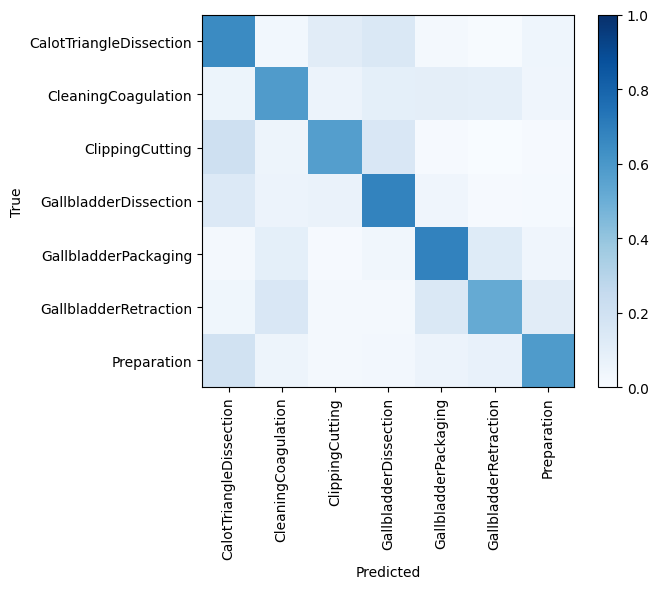

In [ ]:

import matplotlib.pyplot as plt

cm = confusion_matrix(phase_result_endofm["y_true"], phase_result_endofm["pred"], normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(all_phases))); ax.set_xticklabels(all_phases, rotation=90)
ax.set_yticks(range(len(all_phases))); ax.set_yticklabels(all_phases)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "phase_confusion_matrix.png", dpi=150)
plt.show()


In [ ]:

out = {
    "phase": {
        "endofm": {"accuracy": float(phase_result_endofm["accuracy"]), "macro_f1": float(phase_result_endofm["macro_f1"])},
        "random_init_control": {"accuracy": float(phase_result_random["accuracy"]), "macro_f1": float(phase_result_random["macro_f1"])},
        "classes": all_phases,
    },
    "tool": {
        "endofm": {"macro_f1": float(tool_result_endofm["macro_f1"]), "per_tool_f1": dict(zip(TOOL_NAMES, [float(x) for x in tool_result_endofm["per_tool_f1"]]))},
        "random_init_control": {"macro_f1": float(tool_result_random["macro_f1"]), "per_tool_f1": dict(zip(TOOL_NAMES, [float(x) for x in tool_result_random["per_tool_f1"]]))},
        "classes": TOOL_NAMES,
    },
    "n_train_test_frames": {"train": len(train_rows), "test": len(test_rows)},
    "train_video_ids": sorted(TRAIN_IDS),
    "test_video_ids": sorted(TEST_IDS),
}
with open(RESULTS_DIR / "benchmark_results.json", "w") as f:
    json.dump(out, f, indent=2)
print(json.dumps(out, indent=2))


{
  "phase": {
    "endofm": {
      "accuracy": 0.6420147870541988,
      "macro_f1": 0.5592670201805613
    },
    "random_init_control": {
      "accuracy": 0.34285714285714286,
      "macro_f1": 0.3421902467433953
    },
    "classes": [
      "CalotTriangleDissection",
      "CleaningCoagulation",
      "ClippingCutting",
      "GallbladderDissection",
      "GallbladderPackaging",
      "GallbladderRetraction",
      "Preparation"
    ]
  },
  "tool": {
    "endofm": {
      "macro_f1": 0.4853788924588544,
      "per_tool_f1": {
        "Grasper": 0.758590001547748,
        "Bipolar": 0.41928691746209995,
        "Hook": 0.8423988067113224,
        "Scissors": 0.17148579296532732,
        "Clipper": 0.2525403466826061,
        "Irrigator": 0.33201146970898665,
        "SpecimenBag": 0.6213389121338913
      }
    },
    "random_init_control": {
      "macro_f1": 0.3241622683812934,
      "per_tool_f1": {
        "Grasper": 0.6380150642445724,
        "Bipolar": 0.1483375959079284

## 13. Final probes on full data

In [ ]:

import joblib
from datetime import datetime, timezone

full_feats = np.concatenate([endofm_feats["train_f"], endofm_feats["test_f"]])
full_phase = np.concatenate([endofm_feats["train_yp"], endofm_feats["test_yp"]])
full_tool = np.concatenate([endofm_feats["train_yt"], endofm_feats["test_yt"]])

final_phase_clf = LogisticRegression(max_iter=2000, class_weight="balanced")
final_phase_clf.fit(full_feats, full_phase)

final_tool_clf = MultiOutputClassifier(LogisticRegression(max_iter=2000, class_weight="balanced"))
final_tool_clf.fit(full_feats, full_tool)

ARTIFACT_DIR = RESULTS_DIR / "final_model"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_phase_clf, ARTIFACT_DIR / "phase_linear_probe.joblib")
joblib.dump(final_tool_clf, ARTIFACT_DIR / "tool_linear_probe.joblib")

with open(ARTIFACT_DIR / "label_mapping.json", "w") as f:
    json.dump({"phases": all_phases, "phase_to_idx": phase_to_idx, "tool_names": TOOL_NAMES}, f, indent=2)

with open(ARTIFACT_DIR / "metadata.json", "w") as f:
    json.dump({
        "backbone_checkpoint": str(CKPT_PATH),
        "feature_dim": int(full_feats.shape[1]),
        "n_training_frames": int(full_feats.shape[0]),
        "train_video_ids": sorted(TRAIN_IDS),
        "test_video_ids": sorted(TEST_IDS),
        "cholect45_overlap_excluded": False,
        "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    }, f, indent=2)

print("Saved:", ARTIFACT_DIR)


Saved: /content/drive/MyDrive/endofm-benchmark/results/cholec80/final_model
